In [17]:
import numpy as np
import pandas as pd
import os
import joblib
import logging
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

# Load data

In [23]:
train_full = pd.read_parquet('../datasets/processed/features.parquet')
validation = pd.read_parquet('../notebooks/test.parquet')

# Train test split

In [24]:
test = train_full[train_full['date_block_num'] == 33]
train = train_full[train_full['date_block_num'] < 33]

# Baseline modeling

# Lag_1 sales

In [25]:
y_true = test['item_cnt_month']
y_pred_lag1 = test['item_cnt_month_lag_1']

In [26]:
predict_lag_1 = root_mean_squared_error(y_true, y_pred_lag1)
predict_lag_1

1.1629678010940552

But it's on test data what will happen in Kaggle?

In [27]:
validation = validation.merge(
    test[['shop_id', 'item_id', 'item_cnt_month']],  
    on=['shop_id', 'item_id'],                        
    how='left'
)

In [28]:
validation.shape

(214200, 30)

In [29]:
validation['item_cnt_month'] = validation['item_cnt_month'].fillna(0).clip(0,20)

In [30]:
validation['ID'] = validation.index

In [31]:
validation[['ID','item_cnt_month']].to_csv('subm_lag1.csv', index=False)

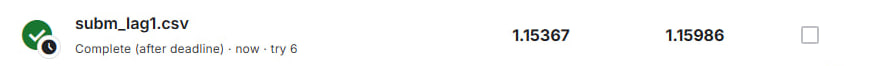

Let's try to get better score 

# Advanced modeling

In [1]:
import numpy as np
import pandas as pd
import os
import joblib
import logging
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
import lightgbm as lgb
from sklearn.metrics import root_mean_squared_error

I think it's more logical to download the data again to start the laptop right from here

## Load data

In [33]:
train_full = pd.read_parquet('../datasets/processed/features.parquet')
validation = pd.read_parquet('../notebooks/test.parquet')

## Cat processing

In [34]:
from category_encoders import TargetEncoder

In [35]:
te = TargetEncoder(cols=['city','type_of_shop'])

In [36]:
te.fit(train_full[['city', 'type_of_shop']], train_full['item_cnt_month'])

TargetEncoder(cols=['city', 'type_of_shop'])

In [37]:
train_full[['city', 'type_of_shop']] = te.transform(train_full[['city', 'type_of_shop']])
validation[['city', 'type_of_shop']] = te.transform(validation[['city', 'type_of_shop']])

In [38]:
def drop_name_columns(df):
    cols_to_drop = [col for col in df.columns if 'name' in col]
    return df.drop(columns=cols_to_drop)

In [39]:
train_full = drop_name_columns(train_full)
validation = drop_name_columns(validation)

In [40]:
train_full = pd.get_dummies(train_full, columns=['season'], prefix='season')
validation = pd.get_dummies(validation, columns=['season'], prefix='season')

## Train test split

In [41]:
test = train_full[train_full['date_block_num'] == 33]
train = train_full[train_full['date_block_num'] < 33]

## Prepare X_train X_test

In [42]:
y_train = train['item_cnt_month']
y_test = test['item_cnt_month']

X_test = test.drop('item_cnt_month', axis=1)
X_train = train.drop('item_cnt_month', axis=1)

In [43]:
print(set(X_train.columns) - set(validation.columns))

{'season_winter', 'season_spring', 'season_summer'}


In [44]:
for col in ['season_winter', 'season_summer', 'season_spring']:
    if col not in validation.columns:
        validation[col] = 0

In [45]:
print(set(X_train.columns) - set(validation.columns))

set()


## Train Lasso

In [15]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer

In [18]:
tscv = TimeSeriesSplit(n_splits=5)

rmse = make_scorer(root_mean_squared_error, squared=False)

## Pipeline setup

In [19]:
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

## Set params

In [20]:
lasso_params = {
    'lasso__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
}

## CV

In [21]:
grid = GridSearchCV(
    lasso_pipeline,
    param_grid=lasso_params,
    scoring=rmse,
    cv=tscv,
    n_jobs=1,
    verbose=2
)

In [22]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


c:\Users\SUPER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\SUPER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\SUPER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\SUPER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                 

[CV] END .................................lasso__alpha=0.001; total time=  37.5s


c:\Users\SUPER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\SUPER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\SUPER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\SUPER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                 

[CV] END .................................lasso__alpha=0.001; total time= 1.4min


...

c:\Users\SUPER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\SUPER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\SUPER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\SUPER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                 

[CV] END ..................................lasso__alpha=10.0; total time=  14.4s


c:\Users\SUPER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\SUPER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\SUPER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\SUPER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                 

[CV] END ..................................lasso__alpha=10.0; total time=  22.9s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('lasso', Lasso(max_iter=10000))]),
             n_jobs=1,
             param_grid={'lasso__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]},
             scoring=make_scorer(root_mean_squared_error, response_method='predict', squared=False),
             verbose=2)

In [23]:
y_pred = grid.predict(X_test)


In [24]:
root_mean_squared_error(y_test, y_pred)


0.8686027446994115

In [48]:
validation.drop('ID', axis=1, inplace=True)

## Make the same order

In [50]:
validation = validation[X_train.columns]

In [51]:
validation.isna().sum()

shop_id                      0
item_id                      0
date_block_num               0
item_price                   0
item_category_id             0
city                         0
type_of_shop                 0
month_sin                    0
month_cos                    0
item_cnt_month_lag_1         0
item_cnt_month_lag_2         0
item_cnt_month_lag_3         0
item_cnt_month_lag_12        0
item_price_lag_1             0
rolling_median_3             0
rolling_median_6             0
item_avg_sales_month_lag1    0
shop_item_avg_lag1           0
log_item_cnt_month_lag_1     0
price_change                 0
price_increasing             0
item_min_price               0
item_max_price               0
price_range                  0
season_autumn                0
season_spring                0
season_summer                0
season_winter                0
dtype: int64

In [58]:
y_pred = grid.predict(validation)

Wow, let's check on kaggle

In [59]:
slon = pd.DataFrame({
    "ID": np.arange(len(y_pred)),
    "item_cnt_month": y_pred.clip(0, 20)
})

In [60]:
slon

,ID,item_cnt_month
0,0,0.000000
1,1,0.000000
2,2,0.927535
3,3,0.012849
4,4,0.000000
...,...,...
214195,214195,0.000000
214196,214196,1.150165
214197,214197,0.605859
214198,214198,0.000000


In [61]:
slon.to_csv('lasso_sub.csv', index= False)

# Light gbm

In [67]:
import os
import joblib
import logging

import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit, train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import root_mean_squared_error

import lightgbm as lgb
from lightgbm import early_stopping
from lightgbm import LGBMRegressor


In [68]:
print(lgb.__file__)
print(lgb.__version__)

e:\AnacondaML\Lib\site-packages\lightgbm\__init__.py
4.6.0


## Load data

In [69]:
train_full = pd.read_parquet('../datasets/processed/features.parquet')
validation = pd.read_parquet('../notebooks/test.parquet')

## Cat processing

In [70]:
from sklearn.preprocessing import LabelEncoder

In [71]:
for col in ['city', 'type_of_shop']:
    le = LabelEncoder()

In [72]:
full_col_data = pd.concat([train_full[col], validation[col]], axis=0)
le.fit(full_col_data)


LabelEncoder()

In [73]:
train_full[col] = le.transform(train_full[col])
validation[col] = le.transform(validation[col])

In [74]:
for col in ['city', 'type_of_shop']:
    le = LabelEncoder()
    train_full[col] = le.fit_transform(train_full[col])
    validation[col] = le.transform(validation[col])

In [75]:
def drop_name_columns(df):
    cols_to_drop = [col for col in df.columns if 'name' in col]
    return df.drop(columns=cols_to_drop)

In [76]:
train_full = drop_name_columns(train_full)
validation = drop_name_columns(validation)

In [77]:
train_full = pd.get_dummies(train_full, columns=['season'], prefix='season')
validation = pd.get_dummies(validation, columns=['season'], prefix='season')

## Train test split

In [78]:
test = train_full[train_full['date_block_num'] == 33]
train = train_full[train_full['date_block_num'] < 33]

## Prepare X_train X_test

In [79]:
y_train = train['item_cnt_month']
y_test = test['item_cnt_month']

X_test = test.drop('item_cnt_month', axis=1)
X_train = train.drop('item_cnt_month', axis=1)

In [80]:
print(set(X_train.columns) - set(validation.columns))

{'season_winter', 'season_summer', 'season_spring'}


In [81]:
bad_cols = [col for col in X_train.columns if X_train[col].nunique() <= 1]
X_train = X_train.drop(columns=bad_cols)
X_test = X_test.drop(columns=bad_cols)
validation = validation.drop(columns=bad_cols)


In [82]:
for col in ['season_winter', 'season_summer', 'season_spring']:
    if col not in validation.columns:
        validation[col] = 0

In [83]:
print(set(X_train.columns) - set(validation.columns))

set()


## model

In [84]:
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_valid = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

## params

In [85]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'max_depth': 6,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42,
    'verbosity': -1  
}


In [86]:
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=['train', 'valid'],
    callbacks=[early_stopping(stopping_rounds=50)]
)


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[30]	train's rmse: 1.141	valid's rmse: 0.727604


In [87]:
train_feature_names = lgb_train.feature_name  # без ()
validation = validation[train_feature_names]


In [88]:
y_pred = model.predict(validation)

In [89]:
lgb_pred = pd.DataFrame({
    "ID": np.arange(len(y_pred)),
    "item_cnt_month": y_pred.clip(0, 20)
})

In [90]:
lgb_pred.to_csv('lgb_sub.csv', index= False)

# Delete features

In [91]:
import shap

In [92]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

In [93]:
print(shap_values.shape, X_train.shape)

(9355190, 28) (9355190, 28)


In [94]:
shap_importance = np.abs(shap_values).mean(axis=0)
shap_summary = pd.DataFrame({
    'feature': X_train.columns,
    'importance': shap_importance
}).sort_values('importance', ascending=False)

In [95]:
TOP_N = 20  
selected_features = shap_summary.head(TOP_N)['feature'].tolist()

print(f"selected {len(selected_features)} features on SHAP.")

selected 20 features on SHAP.


In [66]:
shap_importance = np.abs(shap_values).mean(axis=0)

shap_summary = pd.DataFrame({
    'feature': X_train.columns,
    'importance': shap_importance
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

print(shap_summary)


                      feature  importance
0                  item_price    0.363088
1   item_avg_sales_month_lag1    0.080115
2        item_cnt_month_lag_1    0.067352
3              date_block_num    0.016707
4                price_change    0.013934
5            item_price_lag_1    0.012717
6          shop_item_avg_lag1    0.009820
7            rolling_median_3    0.003710
8            item_category_id    0.003428
9    log_item_cnt_month_lag_1    0.002905
10       item_cnt_month_lag_2    0.002676
11           rolling_median_6    0.001647
12           price_increasing    0.001222
13                  month_cos    0.001165
14                  month_sin    0.000897
15       item_cnt_month_lag_3    0.000886
16                price_range    0.000495
17              season_winter    0.000289
18      item_cnt_month_lag_12    0.000134
19             item_max_price    0.000107
20                    shop_id    0.000077
21                    item_id    0.000066
22             item_min_price    0

In [96]:
X_train = X_train[selected_features]
X_test = X_test[selected_features]
validation = validation[selected_features]